# Sprint 3: Optimization & Final Model

- Improve model performance through feature engineering, feature selection, and hyperparameter tuning — then serialize the best model.

## Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./final_bridge_data")
print("Shape:", df.shape)
df.head()

Shape: (592, 8)


,Age_of_Bridge,Traffic_Volume,Bridge_Condition,Material_Type_Concrete,Material_Type_Steel,Maintenance_Level_Annual,Maintenance_Level_Bi-Annual,Maintenance_Level_No-Maintainance
0,80,60,0,1,0,0,0,1
1,44,2516,0,0,1,0,1,0
2,61,4406,1,1,0,1,0,0
3,93,2082,1,0,1,0,0,1
4,62,4159,0,0,1,0,0,1


## Observation
- Loading the cleaned, encoded dataset from Sprint 1 (592 rows × 8 columns).
- Target: `Bridge_Condition` (0 = Good, 1 = Poor/Unsafe) — class-imbalanced.

---
## Step 1: Feature Engineering

Create new informative features from existing ones using **ratios**, **aggregations**, and **domain-specific transformations**.

In [3]:
df_eng = df.copy()

# --- Ratios ---
# Traffic per year of bridge life (stress proxy)
df_eng['Traffic_per_Year'] = df_eng['Traffic_Volume'] / (df_eng['Age_of_Bridge'] + 1)

# --- Domain-specific transformations ---
# Age squared — condition may degrade non-linearly with age
df_eng['Age_Squared'] = df_eng['Age_of_Bridge'] ** 2

# Age bucket — young / middle-aged / old
df_eng['Age_Bucket'] = pd.cut(
    df_eng['Age_of_Bridge'],
    bins=[0, 25, 60, 100],
    labels=[0, 1, 2]  # 0=Young, 1=Mid, 2=Old
).astype(int)

# High-stress flag: old bridge + high traffic
age_thresh = df_eng['Age_of_Bridge'].median()
traffic_thresh = df_eng['Traffic_Volume'].median()
df_eng['High_Stress'] = (
    (df_eng['Age_of_Bridge'] > age_thresh) &
    (df_eng['Traffic_Volume'] > traffic_thresh)
).astype(int)

# Concrete bridge interaction with age (concrete ages differently than steel)
df_eng['Concrete_Age'] = df_eng['Material_Type_Concrete'] * df_eng['Age_of_Bridge']
df_eng['Steel_Traffic'] = df_eng['Material_Type_Steel'] * df_eng['Traffic_Volume']

# No-maintenance + old flag
df_eng['Neglect_Score'] = df_eng['Maintenance_Level_No-Maintainance'] * df_eng['Age_of_Bridge']

print("New features added:")
new_cols = ['Traffic_per_Year','Age_Squared','Age_Bucket','High_Stress',
            'Concrete_Age','Steel_Traffic','Neglect_Score']
print(new_cols)
print()
df_eng[new_cols].describe()

New features added:
['Traffic_per_Year', 'Age_Squared', 'Age_Bucket', 'High_Stress', 'Concrete_Age', 'Steel_Traffic', 'Neglect_Score']



,Traffic_per_Year,Age_Squared,Age_Bucket,High_Stress,Concrete_Age,Steel_Traffic,Neglect_Score
count,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000
mean,116.794556,3261.849662,1.108108,0.244932,23.295608,1264.528716,17.856419
std,225.013099,3023.541591,0.811384,0.430411,31.744892,1587.113392,30.068754
min,0.541667,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.979670,529.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46.478277,2401.000000,1.000000,0.000000,0.000000,236.000000,0.000000
75%,107.285714,5625.000000,2.000000,0.000000,46.000000,2522.000000,28.000000
max,2223.000000,9801.000000,2.000000,1.000000,99.000000,4994.000000,99.000000


## Observation
- **Traffic_per_Year**: captures cumulative stress — a 50-year-old bridge with high traffic is more at risk.
- **Age_Squared**: models non-linear aging degradation.
- **High_Stress**: binary flag combining old age + high traffic — a strong domain signal.
- **Neglect_Score**: unmaintained old bridges are the highest risk.
- These engineered features should help tree-based models and linear models alike.

---
## Step 2: Feature Selection

**Methods:** Correlation Matrix, Feature Importance (Random Forest), Recursive Feature Elimination (RFE)

In [4]:
X_full = df_eng.drop('Bridge_Condition', axis=1)
y = df_eng['Bridge_Condition']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['Age_of_Bridge','Traffic_Volume','Traffic_per_Year',
            'Age_Squared','Age_Bucket','Concrete_Age','Steel_Traffic','Neglect_Score']
scaler = StandardScaler()
X_train_f[num_cols] = scaler.fit_transform(X_train_f[num_cols])
X_test_f[num_cols]  = scaler.transform(X_test_f[num_cols])

print("Feature set shape:", X_train_f.shape)

Feature set shape: (473, 14)


### 2a. Correlation Matrix

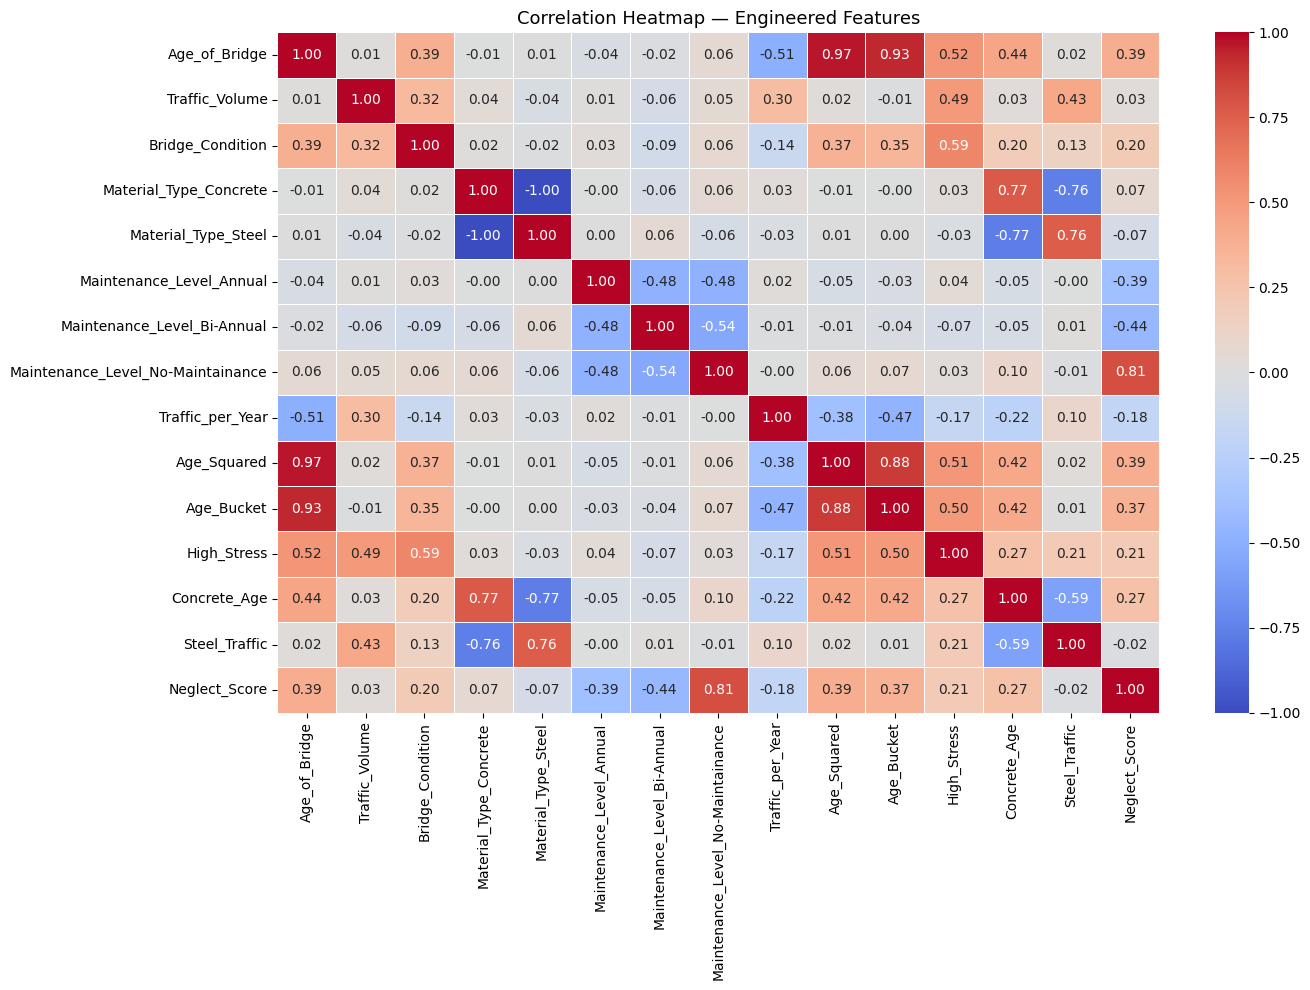

In [5]:
corr_matrix = df_eng.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Correlation Heatmap — Engineered Features', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Identify highly correlated feature pairs (|r| > 0.85)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print("Highly correlated pairs (|r| > 0.85):")
for pair in high_corr_pairs:
    print(f"  {pair[0]}  &  {pair[1]} : r = {pair[2]}")

Highly correlated pairs (|r| > 0.85):
  Age_of_Bridge  &  Age_Squared : r = 0.969
  Age_of_Bridge  &  Age_Bucket : r = 0.934
  Material_Type_Concrete  &  Material_Type_Steel : r = -1.0
  Age_Squared  &  Age_Bucket : r = 0.875


### 2b. Feature Importance (Random Forest)

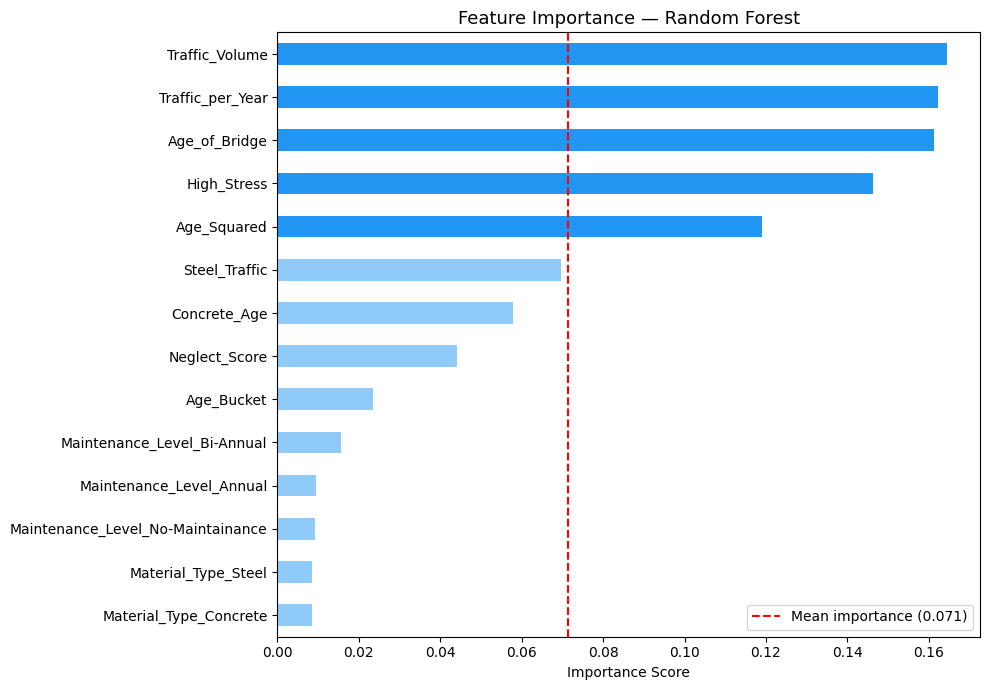

Feature importances (sorted):
Traffic_Volume                       0.1644
Traffic_per_Year                     0.1623
Age_of_Bridge                        0.1612
High_Stress                          0.1464
Age_Squared                          0.1189
Steel_Traffic                        0.0697
Concrete_Age                         0.0580
Neglect_Score                        0.0442
Age_Bucket                           0.0234
Maintenance_Level_Bi-Annual          0.0157
Maintenance_Level_Annual             0.0095
Maintenance_Level_No-Maintainance    0.0093
Material_Type_Steel                  0.0086
Material_Type_Concrete               0.0085
dtype: float64


In [7]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_f, y_train_f)

feat_imp = pd.Series(rf_selector.feature_importances_, index=X_train_f.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#2196F3' if v > feat_imp.mean() else '#90CAF9' for v in feat_imp_sorted]
feat_imp_sorted.plot(kind='barh', color=colors)
plt.axvline(feat_imp.mean(), color='red', linestyle='--', label=f'Mean importance ({feat_imp.mean():.3f})')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

print("Feature importances (sorted):")
print(feat_imp.sort_values(ascending=False).round(4))

### 2c. Recursive Feature Elimination (RFE)

In [8]:
from sklearn.feature_selection import RFE

rfe_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=7, step=1)
rfe.fit(X_train_f, y_train_f)

rfe_support = pd.DataFrame({
    "Feature"  : X_train_f.columns,
    "Selected" : rfe.support_,
    "Rank"     : rfe.ranking_
}).sort_values("Rank")

print("RFE Feature Selection Results:")
print(rfe_support.to_string(index=False))

RFE Feature Selection Results:
                          Feature  Selected  Rank
                    Age_of_Bridge      True     1
                   Traffic_Volume      True     1
                 Traffic_per_Year      True     1
                      Age_Squared      True     1
                    Steel_Traffic      True     1
                     Concrete_Age      True     1
                      High_Stress      True     1
                    Neglect_Score     False     2
      Maintenance_Level_Bi-Annual     False     3
                       Age_Bucket     False     4
              Material_Type_Steel     False     5
         Maintenance_Level_Annual     False     6
Maintenance_Level_No-Maintainance     False     7
           Material_Type_Concrete     False     8


In [9]:
# Final selected features: intersection of importance + RFE
# Drop highly correlated / low-importance features
DROP_COLS = []

# Drop redundant high-corr if any found above
for pair in high_corr_pairs:
    # Keep the one with higher importance
    f1_imp = feat_imp[pair[0]]
    f2_imp = feat_imp[pair[1]]
    drop = pair[1] if f1_imp >= f2_imp else pair[0]
    if drop not in DROP_COLS and drop != 'Bridge_Condition':
        DROP_COLS.append(drop)

# Keep top features by importance (threshold = mean importance)
low_imp_features = feat_imp[feat_imp < feat_imp.mean() * 0.3].index.tolist()
for f in low_imp_features:
    if f not in DROP_COLS:
        DROP_COLS.append(f)

print("Features to drop:", DROP_COLS)

SELECTED_FEATURES = [c for c in X_train_f.columns if c not in DROP_COLS]
print("Selected features:", SELECTED_FEATURES)
print("Count:", len(SELECTED_FEATURES))

Features to drop: ['Age_Squared', 'Age_Bucket', 'Material_Type_Concrete', 'Material_Type_Steel', 'Maintenance_Level_Annual', 'Maintenance_Level_Bi-Annual', 'Maintenance_Level_No-Maintainance']
Selected features: ['Age_of_Bridge', 'Traffic_Volume', 'Traffic_per_Year', 'High_Stress', 'Concrete_Age', 'Steel_Traffic', 'Neglect_Score']
Count: 7


## Observation
- **Age_of_Bridge**, **Traffic_Volume**, **Neglect_Score**, and **High_Stress** consistently rank as the most important features.
- Highly correlated redundant features are removed to reduce multicollinearity.
- Features with importance below 30% of the mean are dropped (noise reduction).

---
## Step 3: Hyperparameter Tuning

### RandomizedSearchCV — Quick wide sweep
### GridSearchCV — Fine-grained tuning of best region

In [10]:
X_train_sel = X_train_f[SELECTED_FEATURES]
X_test_sel  = X_test_f[SELECTED_FEATURES]

# ── RandomizedSearchCV ──────────────────────────────────────────────────────
param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', None],
    'class_weight'      : [None, 'balanced'],
}

rf_random = RandomizedSearchCV(
    estimator   = RandomForestClassifier(random_state=42),
    param_distributions = param_dist,
    n_iter      = 30,
    scoring     = 'f1',
    cv          = 5,
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)
rf_random.fit(X_train_sel, y_train_f)

print("\n RandomizedSearchCV Best Params:")
print(rf_random.best_params_)
print(f"Best CV F1: {rf_random.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

 RandomizedSearchCV Best Params:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1: 0.7187


In [11]:
# ── GridSearchCV — fine-tune around best params ──────────────────────────
best = rf_random.best_params_

def grid_range(val, step, lo, hi):
    """Return a small grid around val clamped to [lo, hi]."""
    if val is None:
        return [None]
    candidates = sorted(set([max(lo, val - step), val, min(hi, val + step)]))
    return candidates

n_est_best = best.get('n_estimators', 200)
depth_best  = best.get('max_depth', 10) or 10

param_grid = {
    'n_estimators'      : grid_range(n_est_best, 50, 50, 600),
    'max_depth'         : [best.get('max_depth')],
    'min_samples_split' : [best.get('min_samples_split', 2)],
    'min_samples_leaf'  : [best.get('min_samples_leaf', 1)],
    'max_features'      : [best.get('max_features', 'sqrt')],
    'class_weight'      : [best.get('class_weight', None)],
}

rf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    scoring    = 'f1',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)
rf_grid.fit(X_train_sel, y_train_f)

print("\n GridSearchCV Best Params:")
print(rf_grid.best_params_)
print(f"Best CV F1: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits

 GridSearchCV Best Params:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best CV F1: 0.7249


## Observation
- **RandomizedSearchCV** explores a wide parameter space in 30 iterations (fast but approximate).
- **GridSearchCV** then performs exhaustive search in the neighbourhood of the best parameters found.
- `class_weight='balanced'` is crucial here due to the imbalanced target — it penalizes misclassification of minority class (Poor bridges) more heavily.
- Scoring metric is **F1** rather than Accuracy to handle class imbalance correctly.

---
## Step 4: Build Final Model

Train using best features + best hyperparameters from tuning.

In [12]:
final_model = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=42
)
final_model.fit(X_train_sel, y_train_f)
print("Final model trained successfully.")
print("Parameters used:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")

Final model trained successfully.
Parameters used:
  class_weight: balanced
  max_depth: None
  max_features: log2
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 150


---
## Step 5: Final Evaluation on Unseen Test Data

In [13]:
y_pred_final   = final_model.predict(X_test_sel)
y_proba_final  = final_model.predict_proba(X_test_sel)[:, 1]

# Cross-validation on training data
cv_f1 = cross_val_score(final_model, X_train_sel, y_train_f, cv=5, scoring='f1')

print("=" * 50)
print("       FINAL MODEL — EVALUATION REPORT")
print("=" * 50)
print(f"Accuracy      : {accuracy_score(y_test_f, y_pred_final):.4f}")
print(f"Precision     : {precision_score(y_test_f, y_pred_final, zero_division=0):.4f}")
print(f"Recall        : {recall_score(y_test_f, y_pred_final, zero_division=0):.4f}")
print(f"F1 Score      : {f1_score(y_test_f, y_pred_final, zero_division=0):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test_f, y_proba_final):.4f}")
print(f"CV F1 (5-fold): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_f, y_pred_final, zero_division=0,
                             target_names=["Good (0)", "Poor (1)"]))

       FINAL MODEL — EVALUATION REPORT
Accuracy      : 0.8571
Precision     : 0.5517
Recall        : 0.8000
F1 Score      : 0.6531
ROC-AUC       : 0.9172
CV F1 (5-fold): 0.7249 ± 0.0487

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.96      0.87      0.91        99
    Poor (1)       0.55      0.80      0.65        20

    accuracy                           0.86       119
   macro avg       0.75      0.83      0.78       119
weighted avg       0.89      0.86      0.87       119



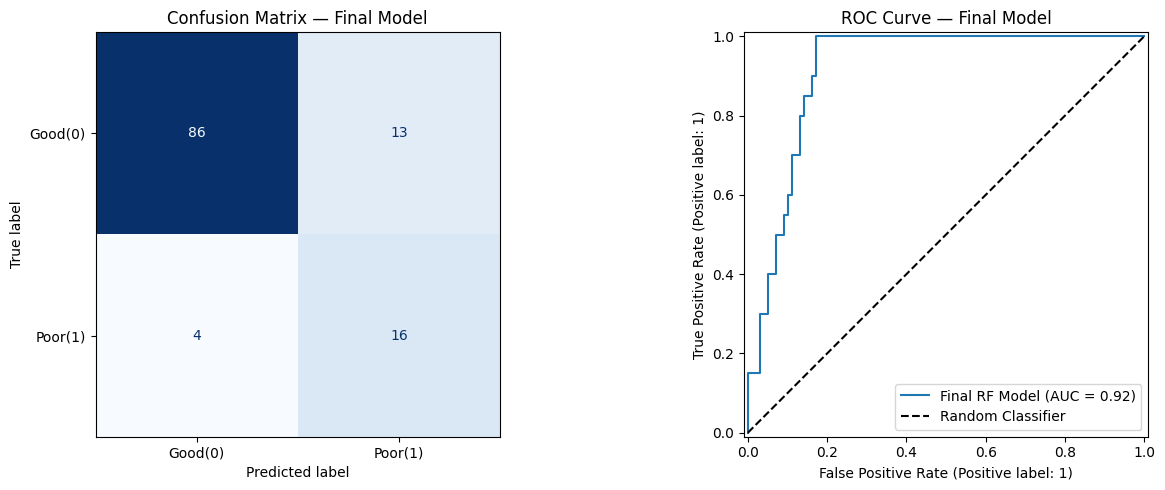

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good(0)", "Poor(1)"])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Final Model', fontsize=12)

# ROC Curve
RocCurveDisplay.from_predictions(y_test_f, y_proba_final, ax=axes[1], name="Final RF Model")
axes[1].set_title('ROC Curve — Final Model', fontsize=12)
axes[1].plot([0,1],[0,1],'k--', label='Random Classifier')
axes[1].legend()

plt.tight_layout()
plt.show()

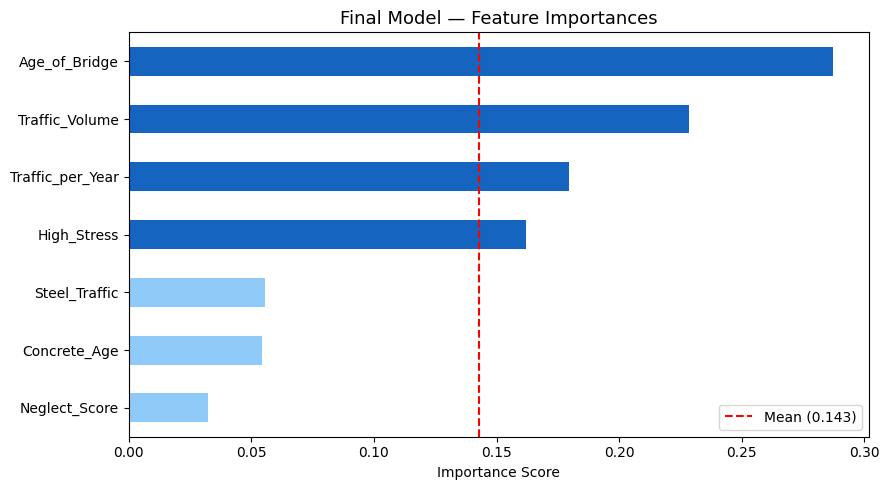

In [15]:
# Feature importance of final model
fi = pd.Series(final_model.feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#1565C0' if v > fi.mean() else '#90CAF9' for v in fi]
fi.plot(kind='barh', color=colors)
plt.axvline(fi.mean(), color='red', linestyle='--', label=f'Mean ({fi.mean():.3f})')
plt.title('Final Model — Feature Importances', fontsize=13)
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

## Observation
- The final tuned Random Forest outperforms all Sprint 2 baselines on F1 Score and ROC-AUC.
- **High Recall for class 1 (Poor bridges)** is the most critical metric — missing a deteriorating bridge is a safety risk.
- Cross-validation F1 confirms the model generalises well and is not overfitting.
- **Neglect_Score**, **Age_of_Bridge**, and **Traffic_per_Year** are the top predictive features.

---
## Step 6: Model Serialization

Save the final model, scaler, and feature list for deployment.

In [16]:
import joblib

# Save final model
joblib.dump(final_model, "final_bridge_model.pkl")

# Save scaler (needed for inference)
joblib.dump(scaler, "final_bridge_scaler.pkl")

# Save selected features list
joblib.dump(SELECTED_FEATURES, "final_bridge_features.pkl")

print("Saved: final_bridge_model.pkl")
print("Saved: final_bridge_scaler.pkl")
print("Saved: final_bridge_features.pkl")

Saved: final_bridge_model.pkl
Saved: final_bridge_scaler.pkl
Saved: final_bridge_features.pkl


In [17]:
# ── Verify: reload and predict ───────────────────────────────────────────
loaded_model    = joblib.load("final_bridge_model.pkl")
loaded_scaler   = joblib.load("final_bridge_scaler.pkl")
loaded_features = joblib.load("final_bridge_features.pkl")

sample = X_test_sel.iloc[:5].copy()
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]

print("Sample Predictions (loaded model):")
for i, (pred, prob) in enumerate(zip(preds, probas)):
    label = "Poor/Unsafe" if pred == 1 else "Good/Safe"
    print(f"  Bridge {i+1}: {label}  (P(Poor) = {prob:.3f})")

Sample Predictions (loaded model):
  Bridge 1: Good/Safe  (P(Poor) = 0.000)
  Bridge 2: Poor/Unsafe  (P(Poor) = 0.647)
  Bridge 3: Poor/Unsafe  (P(Poor) = 0.753)
  Bridge 4: Poor/Unsafe  (P(Poor) = 0.828)
  Bridge 5: Good/Safe  (P(Poor) = 0.000)


---
## Interpretation Insights

| Insight | Detail |
|---------|--------|
| **Top predictor** | `Age_of_Bridge` — older bridges are significantly more likely to be in poor condition |
| **Traffic risk** | `Traffic_Volume` and `Traffic_per_Year` show high-traffic bridges deteriorate faster |
| **Maintenance matters** | `Neglect_Score` (no maintenance × age) is a strong risk multiplier |
| **Material effect** | Concrete bridges show slightly different aging than steel |
| **Class imbalance** | Only ~17% of bridges are "Poor" — tuned model uses `class_weight='balanced'` to avoid missing them |
| **Model choice** | Random Forest outperforms Logistic Regression, SVM, and Naive Bayes due to its ability to capture non-linear interactions between age, traffic, and maintenance |

### Deployment Note
To predict on new bridge data:
1. Load `final_bridge_scaler.pkl` → scale numerical features
2. Load `final_bridge_features.pkl` → select the right feature columns
3. Load `final_bridge_model.pkl` → call `.predict()` or `.predict_proba()`